# Movie Rental Analysis

In [97]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
actor = pd.read_csv('actor.csv')
address = pd.read_csv('address.csv')
category = pd.read_csv('category.csv')
city = pd.read_csv('city.csv')
country = pd.read_csv('country.csv')
customer = pd.read_csv('customer.csv')
film = pd.read_csv('film.csv')
film_actor = pd.read_csv('film_actor.csv')
film_category = pd.read_csv('film_category.csv')
inventory = pd.read_csv('inventory.csv')
language = pd.read_csv('language.csv')
payment = pd.read_csv('payment.csv')
rental = pd.read_csv('rental.csv')
staff = pd.read_csv('staff.csv')
store = pd.read_csv('store.csv')


In [98]:
for a in [rental,payment,actor,city,category,country]:
    for column in list(a.columns):
        if ('date' in column) | ('update' in column):
            a[column]=pd.to_datetime(a[column])

In [99]:
actor.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype                    
---  ------       --------------  -----                    
 0   actor_id     200 non-null    int64                    
 1   first_name   200 non-null    str                      
 2   last_name    200 non-null    str                      
 3   last_update  200 non-null    datetime64[us, UTC+05:30]
dtypes: datetime64[us, UTC+05:30](1), int64(1), str(2)
memory usage: 6.4 KB


## outlier detection

In [100]:
Q1 = payment['amount'].quantile(0.25)
Q3 = payment['amount'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outliers = payment[(payment['amount'] < lower_bound) | (payment['amount'] > upper_bound)]
print(f"Detected {len(outliers)} outliers in payment 'amount'. Capping to upper bound of {upper_bound:.2f}")

# Capping outliers
payment[(payment['amount']>lower_bound) & (payment['amount']<upper_bound)]

Detected 857 outliers in payment 'amount'. Capping to upper bound of 7.99


,payment_id,customer_id,staff_id,rental_id,amount,payment_date
0,16050,269,2,7,1.99,2020-01-25 03:10:19.996577+05:30
1,16051,269,1,98,0.99,2020-01-25 20:46:50.996577+05:30
2,16052,269,2,678,6.99,2020-01-29 03:14:14.996577+05:30
3,16053,269,2,703,0.99,2020-01-29 06:28:02.996577+05:30
4,16054,269,1,750,4.99,2020-01-29 13:40:06.996577+05:30
...,...,...,...,...,...,...
16044,32094,245,2,12682,2.99,2020-05-14 18:14:29.996577+05:30
16045,32095,251,1,14107,0.99,2020-05-14 18:14:29.996577+05:30
16046,32096,252,2,13756,4.99,2020-05-14 18:14:29.996577+05:30
16047,32097,263,1,15293,0.99,2020-05-14 18:14:29.996577+05:30


In [101]:
rental['rental_duration']=rental['return_date']-rental['rental_date']

In [102]:
rental.groupby('customer_id')['rental_duration'].max().reset_index().sort_values(by='rental_duration',ascending=False)

,customer_id,rental_duration
126,127,9 days 05:59:00
382,383,9 days 05:59:00
298,299,9 days 05:58:00
217,218,9 days 05:58:00
85,86,9 days 05:58:00
...,...,...
187,188,7 days 22:13:00
234,235,7 days 21:38:00
454,455,7 days 20:15:00
394,395,7 days 19:05:00


In [103]:
payment['month']=payment['payment_date'].dt.strftime('%b')

In [104]:
monthly_revenue=payment.groupby('month')['amount'].sum().reset_index()

In [105]:
monthly_revenue

,month,amount
0,Apr,27530.83
1,Feb,9685.74
2,Jan,4770.57
3,Mar,23886.56
4,May,1542.81


<Axes: xlabel='month', ylabel='amount'>

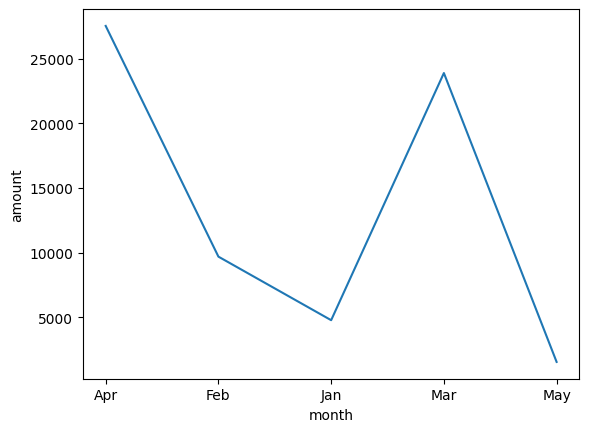

In [106]:
plt.figure()
sns.lineplot(data=monthly_revenue,x='month',y='amount')
